In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
import os
print (os.getcwd())

/content


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for name in dirs + files:
        if 'banana leaf' in name.lower():
            print(os.path.join(root, name))

/content/drive/MyDrive/banana leaf
/content/drive/MyDrive/Banana and Banana Leaf Dataset for Classification
/content/drive/MyDrive/banana leaf dataset Augmented.zip
/content/drive/MyDrive/ Banana Leaf v2.zip
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test/Chewing insect damage on banana leaf
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/validation/Chewing insect damage on banana leaf
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train/Chewing insect damage on banana leaf
/content/drive/MyDrive/Banana and Banana Leaf Dataset for Classification/Banana and Banana Leaf Dataset for Classification
/content/drive/MyDrive/Banana and Banana Leaf Dataset for Classification/Banana and Banana Leaf Dataset for Classification/RAW/Banana and banana leaf dataset Raw.zip
/content/drive/MyDrive/Banana and Banana Leaf Dataset for Classification/Banana and Banana Leaf Dataset for Classification/AUGMENTED/Banana and banana leaf dataset Augmented.zip


In [5]:
!nvidia-smi

Thu Sep 10 08:43:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
ZIP_PATH = "/content/banana leaf dataset Augmented.zip"
EXTRACT_DIR = "/content/BananaDataset"

!unzip -q "$ZIP_PATH" -d "$EXTRACT_DIR"

print("Dataset extracted to:", EXTRACT_DIR)


unzip:  cannot find or open /content/banana leaf dataset Augmented.zip, /content/banana leaf dataset Augmented.zip.zip or /content/banana leaf dataset Augmented.zip.ZIP.
Dataset extracted to: /content/BananaDataset


In [7]:
import os

# ค้นหาโฟลเดอร์ train ทั้งหมดใน /content
train_folders = []

for root, dirs, files in os.walk("/content"):
    if "train" in dirs:
        train_folders.append(os.path.join(root, "train"))

print("พบโฟลเดอร์ train:")
for x in train_folders:
    print(x)


พบโฟลเดอร์ train:
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train
/content/drive/.Encrypted/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train


In [8]:
import os

train_dir = train_folders[0]

# เอาโฟลเดอร์แม่ของ train
DATASET_PATH = os.path.dirname(train_dir)

val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

print("DATASET_PATH =", DATASET_PATH)
print("train_dir =", train_dir)
print("val_dir =", val_dir)
print("test_dir =", test_dir)

print("\nตรวจสอบ:")
print("Train:", os.path.isdir(train_dir))
print("Validation:", os.path.isdir(val_dir))
print("Test:", os.path.isdir(test_dir))

DATASET_PATH = /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH
train_dir = /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train
val_dir = /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/validation
test_dir = /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test

ตรวจสอบ:
Train: True
Validation: True
Test: True


In [9]:

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for split_name, split_dir in [
    ("Train", train_dir),
    ("Validation", val_dir),
    ("Test", test_dir)
]:
    print("\n==========", split_name, "==========")
    total = 0

    for class_name in sorted(os.listdir(split_dir)):
        class_path = os.path.join(split_dir, class_name)

        if os.path.isdir(class_path):
            images = [
                f for f in os.listdir(class_path)
                if f.lower().endswith(image_extensions)
            ]

            print(f"{class_name}: {len(images)} images")
            total += len(images)

    print("Total =", total)



========== Train ==========
Banana Skipper Damage: 845 images
Black and Yellow Sigatoka: 845 images
Chewing insect damage on banana leaf: 845 images
Healthy Banana  leaf: 845 images
Panama Wilt Disease: 845 images
Total = 4225

========== Validation ==========
Banana Skipper Damage: 105 images
Black and Yellow Sigatoka: 105 images
Chewing insect damage on banana leaf: 105 images
Healthy Banana  leaf: 105 images
Panama Wilt Disease: 105 images
Total = 525

========== Test ==========
Banana Skipper Damage: 107 images
Black and Yellow Sigatoka: 107 images
Chewing insect damage on banana leaf: 107 images
Healthy Banana  leaf: 107 images
Panama Wilt Disease: 107 images
Total = 535


In [10]:

import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from torchvision.models import (
    mobilenet_v2,
    MobileNet_V2_Weights
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [11]:
import torch

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
NUM_WORKERS = 2
SEED = 42

# ตรวจสอบ GPU / CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


Device: cuda


In [12]:
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("Random seed =", SEED)



Random seed = 42


In [13]:
import torch
from torchvision import transforms

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [14]:
import os

print("===== /content =====")
print(os.listdir("/content"))

print("\n===== ค้นหา train / validation / test =====")

for root, dirs, files in os.walk("/content"):
    for d in dirs:
        if d.lower() in ["train", "validation", "valid", "test"]:
            print(os.path.join(root, d))

===== /content =====
['.config', 'drive', 'sample_data']

===== ค้นหา train / validation / test =====
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/validation
/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train
/content/drive/.Encrypted/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test
/content/drive/.Encrypted/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/validation
/content/drive/.Encrypted/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train


In [15]:
DATASET_PATH = "/content/BananaDataset"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

In [16]:
import os

DATASET_PATH = "/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH"

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "validation")
test_dir = os.path.join(DATASET_PATH, "test")

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

print("\nตรวจสอบ:")
print("Train มีอยู่:", os.path.isdir(train_dir))
print("Validation มีอยู่:", os.path.isdir(val_dir))
print("Test มีอยู่:", os.path.isdir(test_dir))

Train: /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/train
Validation: /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/validation
Test: /content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test

ตรวจสอบ:
Train มีอยู่: True
Validation มีอยู่: True
Test มีอยู่: True


In [17]:
import torch
from torchvision import datasets

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

print("Train images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Test images:", len(test_dataset))
print("Classes:", train_dataset.classes)

Train images: 4225
Validation images: 525
Test images: 535
Classes: ['Banana Skipper Damage', 'Black and Yellow Sigatoka', 'Chewing insect damage on banana leaf', 'Healthy Banana  leaf', 'Panama Wilt Disease']


In [18]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 133
Validation batches: 17
Test batches: 17


In [19]:
class_names = train_dataset.classes
NUM_CLASSES = len(class_names)

print("Classes:")

for i, class_name in enumerate(class_names):
    print(i, "=", class_name)

print("\nNumber of classes =", NUM_CLASSES)


Classes:
0 = Banana Skipper Damage
1 = Black and Yellow Sigatoka
2 = Chewing insect damage on banana leaf
3 = Healthy Banana  leaf
4 = Panama Wilt Disease

Number of classes = 5


In [20]:
print("Train:")
print(train_dataset.class_to_idx)

print("\nValidation:")
print(val_dataset.class_to_idx)

print("\nTest:")
print(test_dataset.class_to_idx)

Train:
{'Banana Skipper Damage': 0, 'Black and Yellow Sigatoka': 1, 'Chewing insect damage on banana leaf': 2, 'Healthy Banana  leaf': 3, 'Panama Wilt Disease': 4}

Validation:
{'Banana Skipper Damage': 0, 'Black and Yellow Sigatoka': 1, 'Chewing insect damage on banana leaf': 2, 'Healthy Banana  leaf': 3, 'Panama Wilt Disease': 4}

Test:
{'Banana Skipper Damage': 0, 'Black and Yellow Sigatoka': 1, 'Chewing insect damage on banana leaf': 2, 'Healthy Banana  leaf': 3, 'Panama Wilt Disease': 4}


In [21]:
print("========== TRAIN ==========")
for k, v in train_dataset.class_to_idx.items():
    print(repr(k), "->", v)

print("\n========== VALIDATION ==========")
for k, v in val_dataset.class_to_idx.items():
    print(repr(k), "->", v)

print("\n========== TEST ==========")
for k, v in test_dataset.class_to_idx.items():
    print(repr(k), "->", v)

========== TRAIN ==========
'Banana Skipper Damage' -> 0
'Black and Yellow Sigatoka' -> 1
'Chewing insect damage on banana leaf' -> 2
'Healthy Banana  leaf' -> 3
'Panama Wilt Disease' -> 4

========== VALIDATION ==========
'Banana Skipper Damage' -> 0
'Black and Yellow Sigatoka' -> 1
'Chewing insect damage on banana leaf' -> 2
'Healthy Banana  leaf' -> 3
'Panama Wilt Disease' -> 4

========== TEST ==========
'Banana Skipper Damage' -> 0
'Black and Yellow Sigatoka' -> 1
'Chewing insect damage on banana leaf' -> 2
'Healthy Banana  leaf' -> 3
'Panama Wilt Disease' -> 4


In [22]:
import os

old_name = "/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test/Panama_Disease"
new_name = "/content/drive/MyDrive/banana leaf/SHOWROV AZAM BANANA RESEARCH/test/Panama Wilt Disease"

if os.path.exists(old_name):
    os.rename(old_name, new_name)
    print("เปลี่ยนชื่อสำเร็จ")
else:
    print("ไม่พบโฟลเดอร์ Panama_Disease")

ไม่พบโฟลเดอร์ Panama_Disease


In [23]:
from torchvision import datasets

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=transform
)

print("Test classes:")
print(test_dataset.class_to_idx)

Test classes:
{'Banana Skipper Damage': 0, 'Black and Yellow Sigatoka': 1, 'Chewing insect damage on banana leaf': 2, 'Healthy Banana  leaf': 3, 'Panama Wilt Disease': 4}


In [24]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))


Train batches: 133
Validation batches: 17
Test batches: 17


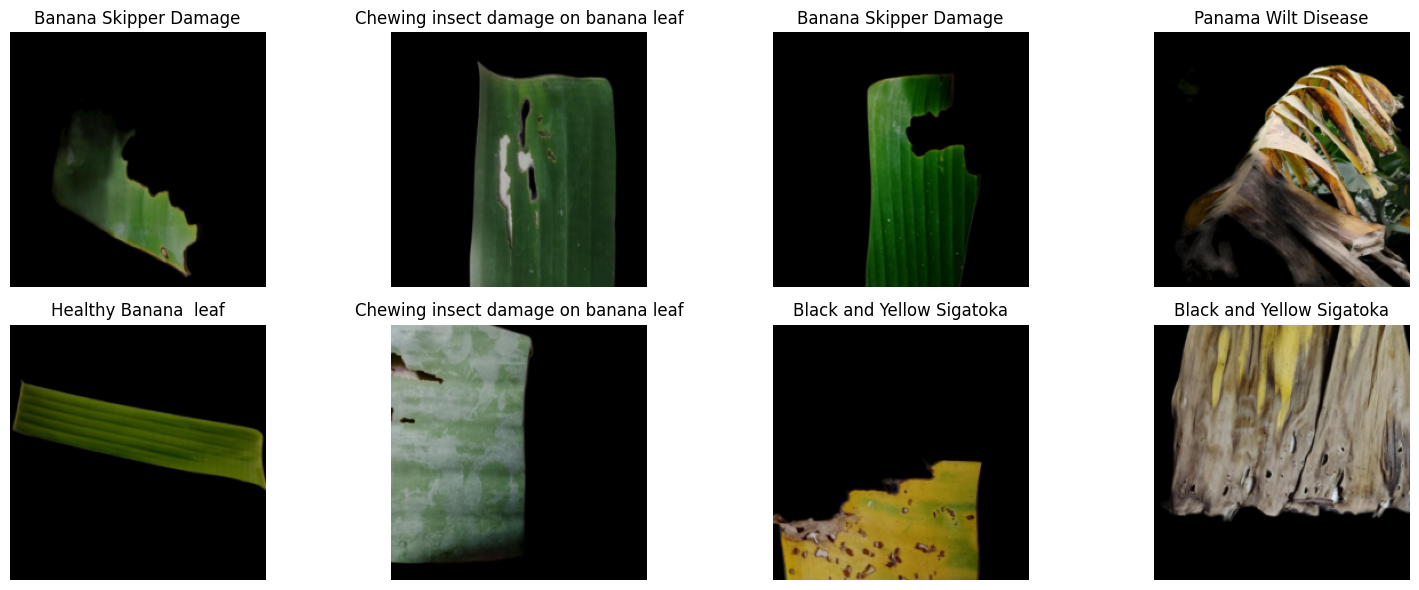

In [25]:
import matplotlib.pyplot as plt
def denormalize_image(img_tensor):
    mean = torch.tensor(
        [0.485, 0.456, 0.406]
    ).view(3, 1, 1)

    std = torch.tensor(
        [0.229, 0.224, 0.225]
    ).view(3, 1, 1)

    img_tensor = img_tensor.cpu()
    img_tensor = img_tensor * std + mean
    img_tensor = torch.clamp(img_tensor, 0, 1)

    return img_tensor


images, labels = next(iter(train_loader))
num_show = min(8, len(images))

plt.figure(figsize=(16, 6))

for i in range(num_show):
    img = denormalize_image(images[i])
    img = img.permute(1, 2, 0).numpy()

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()


In [26]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

# โหลดน้ำหนัก MobileNetV2 ที่ฝึกจาก ImageNet
weights = MobileNet_V2_Weights.DEFAULT

# สร้างโมเดล
model = mobilenet_v2(weights=weights)

# เปลี่ยน classifier จาก 1000 classes เป็น 5 classes
num_classes = len(train_dataset.classes)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

# ย้ายโมเดลไป GPU/CPU
model = model.to(device)

print("MobileNetV2 loaded successfully!")
print("Number of classes:", num_classes)
print("Classes:", train_dataset.classes)
print("Device:", device)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 69.6MB/s]

MobileNetV2 loaded successfully!
Number of classes: 5
Classes: ['Banana Skipper Damage', 'Black and Yellow Sigatoka', 'Chewing insect damage on banana leaf', 'Healthy Banana  leaf', 'Panama Wilt Disease']
Device: cuda


In [27]:
for param in model.features.parameters():
    param.requires_grad = False

print("MobileNetV2 feature extractor frozen.")


MobileNetV2 feature extractor frozen.


In [28]:
in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2),
    nn.Linear(
        in_features,
        NUM_CLASSES
    )
)

model = model.to(device)

print(model.classifier)


Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1280, out_features=5, bias=True)
)


In [29]:
 total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

frozen_params = total_params - trainable_params

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Frozen parameters    : {frozen_params:,}")


Total parameters     : 2,230,277
Trainable parameters : 6,405
Frozen parameters    : 2,223,872


In [30]:
import torch.nn as nn
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=LEARNING_RATE
)

print("Loss      : CrossEntropyLoss")
print("Optimizer : Adam")
print("LR        :", LEARNING_RATE)

Loss      : CrossEntropyLoss
Optimizer : Adam
LR        : 0.001


In [31]:
print("model      :", "OK" if model is not None else "NO")
print("train_loader:", "OK" if train_loader is not None else "NO")
print("val_loader  :", "OK" if val_loader is not None else "NO")
print("test_loader :", "OK" if test_loader is not None else "NO")
print("criterion   :", "OK" if criterion is not None else "NO")
print("optimizer   :", "OK" if optimizer is not None else "NO")
print("device      :", device)

model      : OK
train_loader: OK
val_loader  : OK
test_loader : OK
criterion   : OK
optimizer   : OK
device      : cuda


In [32]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item() * images.size(0)
        )

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return epoch_loss, epoch_acc


In [33]:
def evaluate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predicted.cpu().numpy()
            )

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total

    return (
        epoch_loss,
        epoch_acc,
        np.array(all_labels),
        np.array(all_predictions)
    )


In [35]:
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_acc = -1.0

BEST_MODEL_PATH = (
    "/content/best_mobilenetv2_banana.pth"
)

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    (
        val_loss,
        val_acc,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch + 1:02d}/{NUM_EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.2f}%"
    )

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "class_names":
                    class_names,

                "class_to_idx":
                    train_dataset.class_to_idx,

                "best_val_acc":
                    best_val_acc,

                "img_size":
                    IMG_SIZE,

                "num_classes":
                    NUM_CLASSES
            },
            BEST_MODEL_PATH
        )

        print(
            f"  -> Best model saved "
            f"(Val Acc = {best_val_acc:.2f}%)"
        )

print("\nTraining completed.")


Epoch [01/15] | Train Loss: 0.6220 | Train Acc: 87.79% | Val Loss: 0.3230 | Val Acc: 93.33%
  -> Best model saved (Val Acc = 93.33%)
Epoch [02/15] | Train Loss: 0.2927 | Train Acc: 93.54% | Val Loss: 0.2174 | Val Acc: 94.86%
  -> Best model saved (Val Acc = 94.86%)
Epoch [03/15] | Train Loss: 0.2095 | Train Acc: 95.31% | Val Loss: 0.1797 | Val Acc: 96.19%
  -> Best model saved (Val Acc = 96.19%)
Epoch [04/15] | Train Loss: 0.1645 | Train Acc: 96.17% | Val Loss: 0.1278 | Val Acc: 97.71%
  -> Best model saved (Val Acc = 97.71%)
Epoch [05/15] | Train Loss: 0.1447 | Train Acc: 96.40% | Val Loss: 0.1091 | Val Acc: 97.52%
Epoch [06/15] | Train Loss: 0.1277 | Train Acc: 96.83% | Val Loss: 0.1254 | Val Acc: 96.76%
Epoch [07/15] | Train Loss: 0.1161 | Train Acc: 97.04% | Val Loss: 0.0733 | Val Acc: 97.52%
Epoch [08/15] | Train Loss: 0.1088 | Train Acc: 96.71% | Val Loss: 0.0862 | Val Acc: 97.52%
Epoch [09/15] | Train Loss: 0.1039 | Train Acc: 96.90% | Val Loss: 0.0671 | Val Acc: 98.10%
  -> Bes

In [36]:
print("NUM_EPOCHS:", "NUM_EPOCHS" in globals())
print("train_losses:", "train_losses" in globals())
print("val_losses:", "val_losses" in globals())
print("train_accuracies:", "train_accuracies" in globals())
print("val_accuracies:", "val_accuracies" in globals())


NUM_EPOCHS: True
train_losses: True
val_losses: True
train_accuracies: True
val_accuracies: True


In [37]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [38]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [41]:
num_classes = len(train_loader.dataset.classes)

print("Classes:", train_loader.dataset.classes)
print("Number of classes:", num_classes)

Classes: ['Banana Skipper Damage', 'Black and Yellow Sigatoka', 'Chewing insect damage on banana leaf', 'Healthy Banana  leaf', 'Panama Wilt Disease']
Number of classes: 5


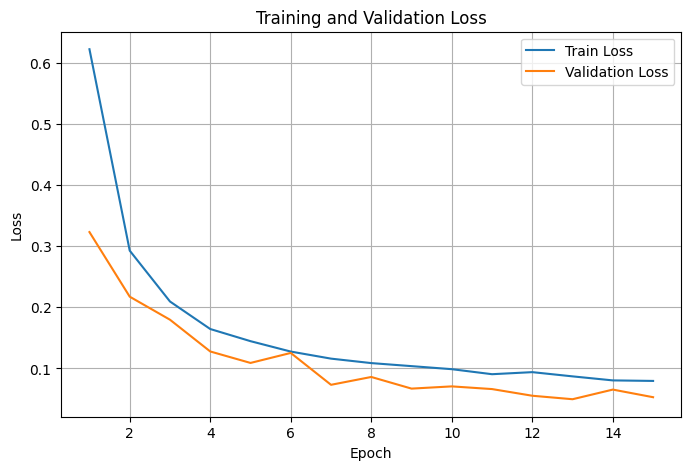

In [42]:
epochs_range = range(
    1,
    NUM_EPOCHS + 1
)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Train Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()


In [43]:
# ทดสอบโมเดลกับ Test Dataset

model.eval()

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)
        test_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# คำนวณผลลัพธ์
test_loss = test_loss / total
test_accuracy = correct / total

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.0553
Test Accuracy: 98.13%


In [44]:
print(test_loader)

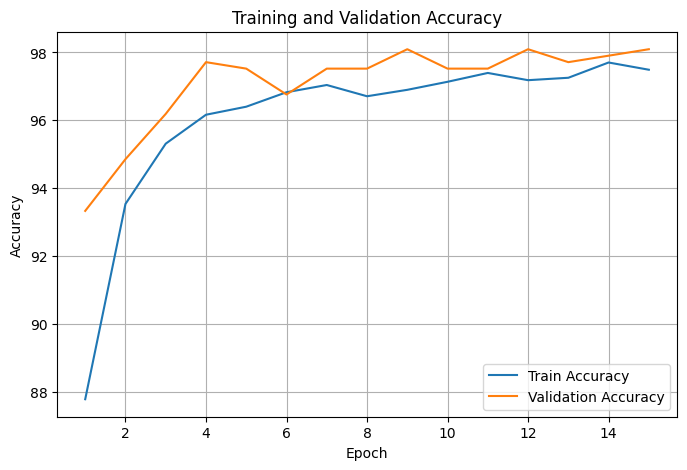

In [45]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()


In [57]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

class_names = checkpoint[
    "class_names"
]

model = model.to(device)

print(
    f"Best Validation Accuracy: "
    f"{checkpoint['best_val_acc']:.2f}%"
)


Best Validation Accuracy: 98.10%


In [46]:
(
    test_loss,
    test_acc,
    y_true,
    y_pred
) = evaluate(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.2f}%")


Test Loss     : 0.0553
Test Accuracy : 98.13%


In [47]:
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision_macro, recall_macro, f1_macro, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )
)

precision_weighted, recall_weighted, f1_weighted, _ = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )
)

print("\n========== Test Metrics ==========")

print(
    f"Accuracy           : "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Macro Precision    : "
    f"{precision_macro * 100:.2f}%"
)

print(
    f"Macro Recall       : "
    f"{recall_macro * 100:.2f}%"
)

print(
    f"Macro F1-score     : "
    f"{f1_macro * 100:.2f}%"
)

print(
    f"Weighted Precision : "
    f"{precision_weighted * 100:.2f}%"
)

print(
    f"Weighted Recall    : "
    f"{recall_weighted * 100:.2f}%"
)

print(
    f"Weighted F1-score  : "
    f"{f1_weighted * 100:.2f}%"
)



========== Test Metrics ==========
Accuracy           : 98.13%
Macro Precision    : 98.14%
Macro Recall       : 98.13%
Macro F1-score     : 98.13%
Weighted Precision : 98.14%
Weighted Recall    : 98.13%
Weighted F1-score  : 98.13%


In [48]:
print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)



Classification Report:

                                      precision    recall  f1-score   support

               Banana Skipper Damage     1.0000    1.0000    1.0000       107
           Black and Yellow Sigatoka     0.9619    0.9439    0.9528       107
Chewing insect damage on banana leaf     1.0000    1.0000    1.0000       107
                Healthy Banana  leaf     1.0000    1.0000    1.0000       107
                 Panama Wilt Disease     0.9450    0.9626    0.9537       107

                            accuracy                         0.9813       535
                           macro avg     0.9814    0.9813    0.9813       535
                        weighted avg     0.9814    0.9813    0.9813       535



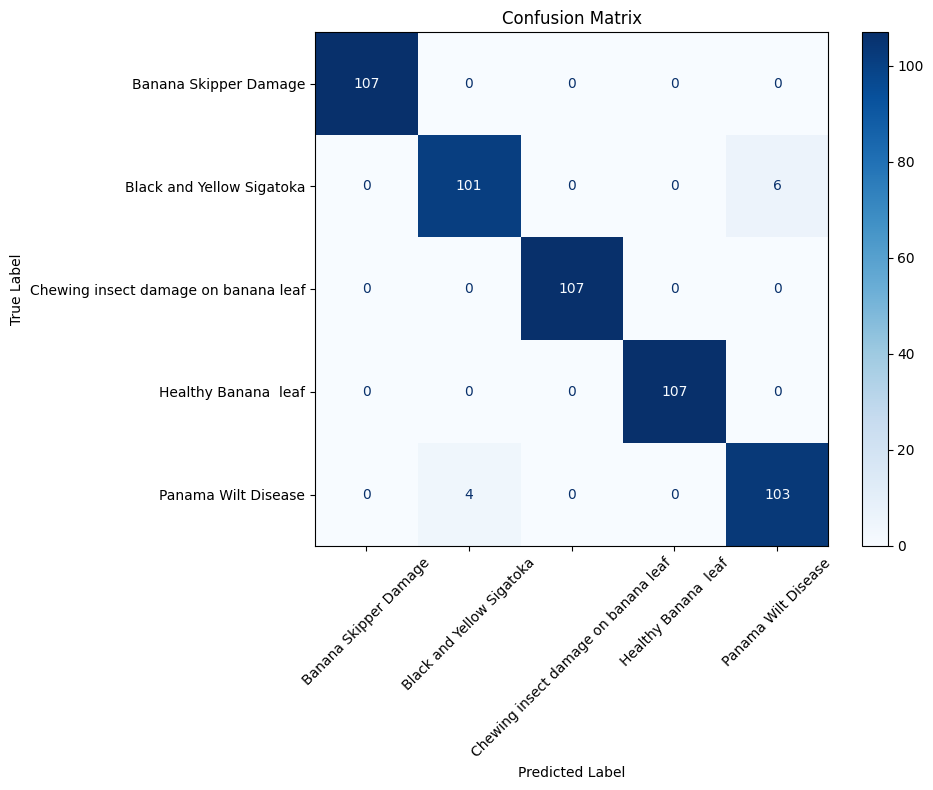

In [49]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ชื่อคลาส
class_names = test_dataset.classes

# สร้าง Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# สร้างกราฟ
fig, ax = plt.subplots(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


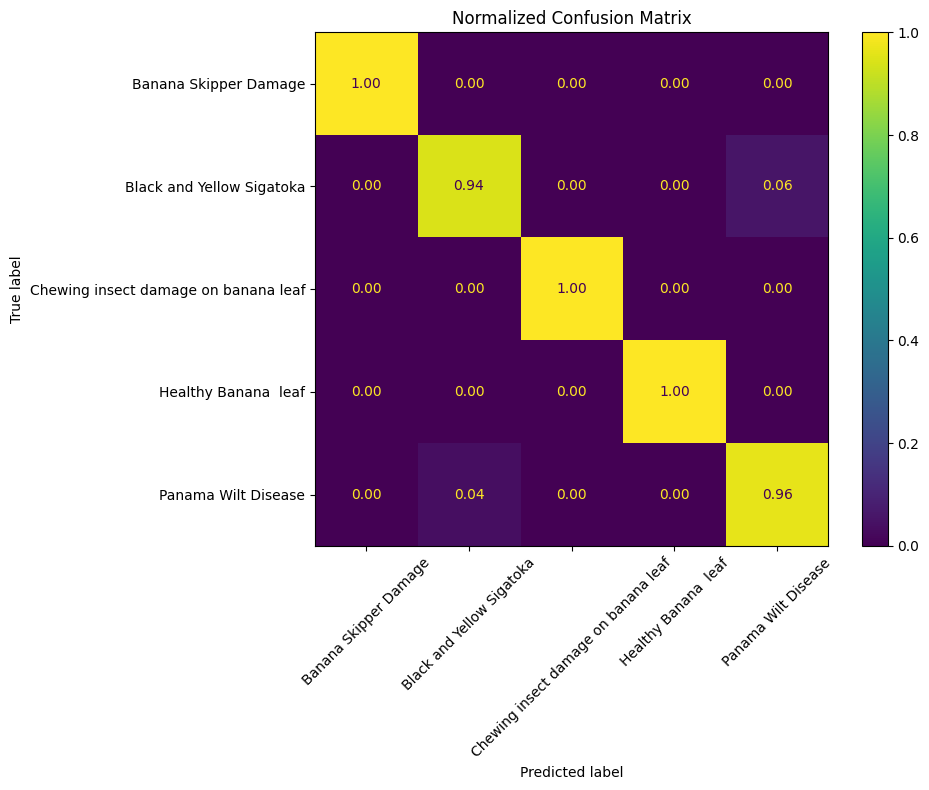

In [50]:
cm_normalized = confusion_matrix(
    y_true,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
    cmap=None
)

plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()


In [51]:
FINAL_MODEL_PATH = (
    "/content/mobilenetv2_banana_final.pth"
)

torch.save(
    {
        "model_state_dict":
            model.state_dict(),

        "class_names":
            class_names,

        "class_to_idx":
            train_dataset.class_to_idx,

        "img_size":
            IMG_SIZE,

        "num_classes":
            NUM_CLASSES
    },
    FINAL_MODEL_PATH
)

print(
    "Model saved to:",
    FINAL_MODEL_PATH
)


Model saved to: /content/mobilenetv2_banana_final.pth


In [52]:
def predict_image(
    image_path,
    model,
    transform,
    class_names,
    device
):
    model.eval()

    image = Image.open(
        image_path
    ).convert("RGB")

    input_tensor = transform(
        image
    )

    input_tensor = (
        input_tensor
        .unsqueeze(0)
        .to(device)
    )

    with torch.no_grad():

        logits = model(
            input_tensor
        )

        probabilities = torch.softmax(
            logits,
            dim=1
        )

        confidence, predicted_idx = torch.max(
            probabilities,
            1
        )

    predicted_class = class_names[
        predicted_idx.item()
    ]

    confidence = (
        confidence.item() * 100
    )

    return (
        predicted_class,
        confidence,
        probabilities.cpu().numpy()[0]
    )


In [53]:
from google.colab import files

uploaded = files.upload()


Saving Screenshot 2026-09-10 134148.png to Screenshot 2026-09-10 134148.png



Image: Screenshot 2026-09-10 134148.png
Prediction: Healthy Banana  leaf
Confidence: 76.63%

Probabilities:
Banana Skipper Damage: 5.16%
Black and Yellow Sigatoka: 0.16%
Chewing insect damage on banana leaf: 12.12%
Healthy Banana  leaf: 76.63%
Panama Wilt Disease: 5.93%


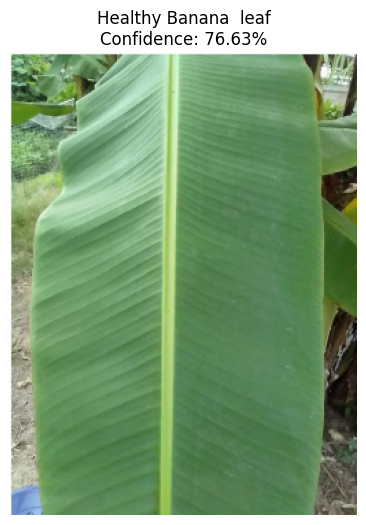

In [54]:
for filename in uploaded.keys():

    (
        predicted_class,
        confidence,
        probabilities
    ) = predict_image(
        filename,
        model,
        transform,
        class_names,
        device
    )

    print("\nImage:", filename)
    print("Prediction:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")

    print("\nProbabilities:")

    for class_name, prob in zip(
        class_names,
        probabilities
    ):
        print(
            f"{class_name}: "
            f"{prob * 100:.2f}%"
        )

    img = Image.open(
        filename
    ).convert("RGB")

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"{predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.show()


In [55]:
for filename in uploaded.keys():

    (
        predicted_class,
        confidence,
        probabilities
    ) = predict_image(
        filename,
        model,
        transform,
        class_names,
        device
    )

    top3_idx = np.argsort(
        probabilities
    )[::-1][:3]

    print("\nImage:", filename)
    print("Top-3 predictions:")

    for rank, idx in enumerate(
        top3_idx,
        start=1
    ):
        print(
            f"{rank}. "
            f"{class_names[idx]} "
            f"= "
            f"{probabilities[idx] * 100:.2f}%"
        )



Image: Screenshot 2026-09-10 134148.png
Top-3 predictions:
1. Healthy Banana  leaf = 76.63%
2. Chewing insect damage on banana leaf = 12.12%
3. Panama Wilt Disease = 5.93%


In [56]:
from google.colab import files

print("Best model:", BEST_MODEL_PATH)
print("Final model:", FINAL_MODEL_PATH)

# Uncomment เมื่อต้องการดาวน์โหลด
# files.download(BEST_MODEL_PATH)
# files.download(FINAL_MODEL_PATH)


Best model: /content/best_mobilenetv2_banana.pth
Final model: /content/mobilenetv2_banana_final.pth
